In [1]:
import torch
import pandas as pd
import glob
import numpy as np
import os.path
import tqdm
import matplotlib.pyplot as plt
import torch
from neml2.postprocessing import polefigure
import scipy.interpolate as inter

import neml2

import helpers, taylor

In [2]:
torch.set_default_dtype(torch.double)

In [3]:
# Inputs for deformation modeling
axial_index = 2
assumed_rate = 1.0e-4
d = torch.zeros((6,))
d[axial_index] = 1.0

In [4]:
get_stress = lambda s: float(os.path.basename(s).split(".")[0])
files = sorted(glob.glob('ff/*.csv'), key = get_stress)
stress_levels = [get_stress(f) for f in files]
data = [pd.read_csv(f) for f in files]
strain_stress = np.loadtxt('strain-stress.csv', delimiter = ',')

In [5]:
exp_strain = [helpers.load_strains(d) for d in data]
exp_texture = [helpers.load_orientations(d) for d in data]
avg_exp_strain = [torch.mean(ds, dim = 0) for ds in exp_strain]
avg_axial_strain = [s[axial_index] - avg_exp_strain[0][axial_index] for s in avg_exp_strain]

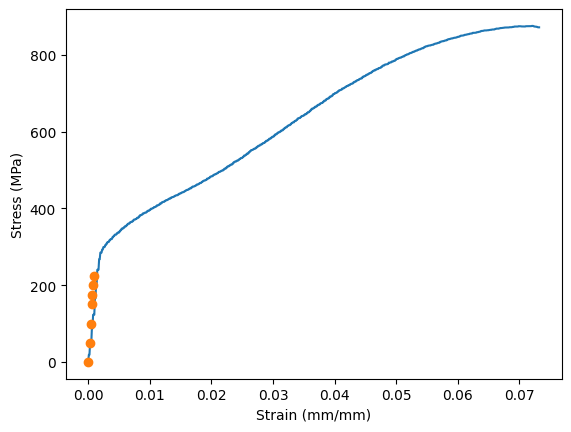

In [6]:
plt.figure()
plt.plot(strain_stress[:,0], strain_stress[:,1])
plt.plot(avg_axial_strain, stress_levels, 'o')
plt.xlabel('Strain (mm/mm)')
plt.ylabel("Stress (MPa)")
plt.show()

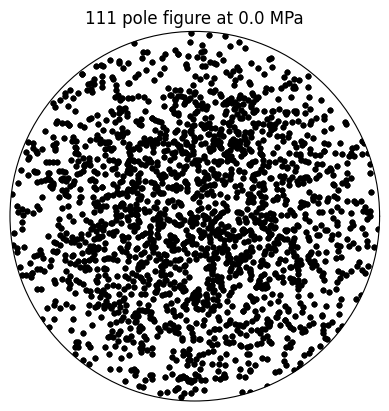

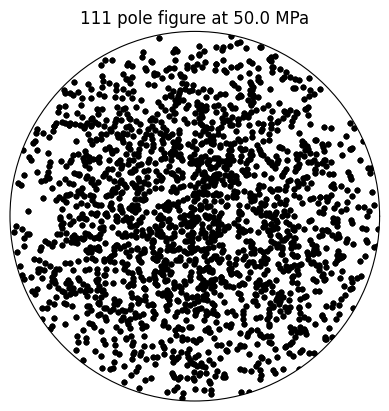

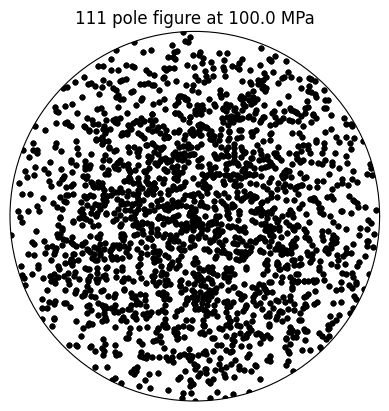

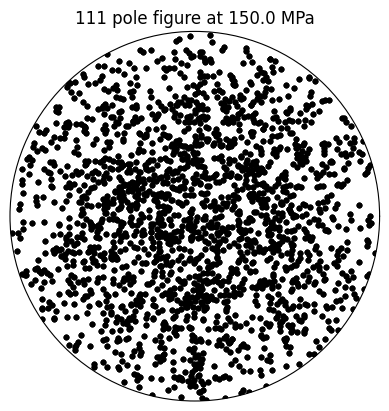

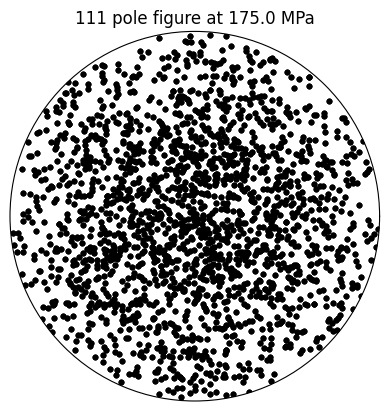

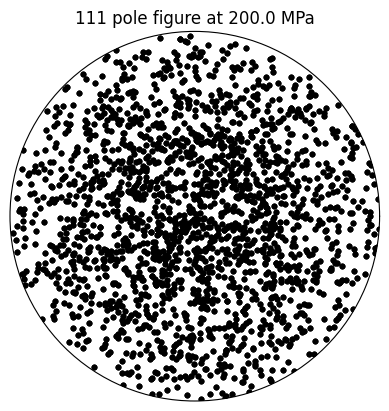

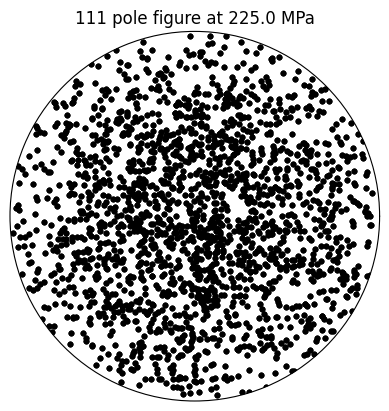

In [7]:
# Plot experimental texture
for stress, t in zip(stress_levels, exp_texture):
    polefigure.pretty_plot_pole_figure_points(t, torch.tensor([1.0, 1.0, 1.0]), crystal_symmetry = "432")
    plt.title(f'111 pole figure at {stress} MPa')
    plt.show()

In [8]:
model = neml2.load_model('models/template.i', 'model_with_stress')
tmodel = taylor.UniaxialTaylorModel(model)
old_state = tmodel.initial_state(exp_texture[0])
old_stress = torch.zeros(old_state.shape[0], 6)
old_time = 0.0

100%|██████████| 747/747 [05:59<00:00,  2.08it/s]


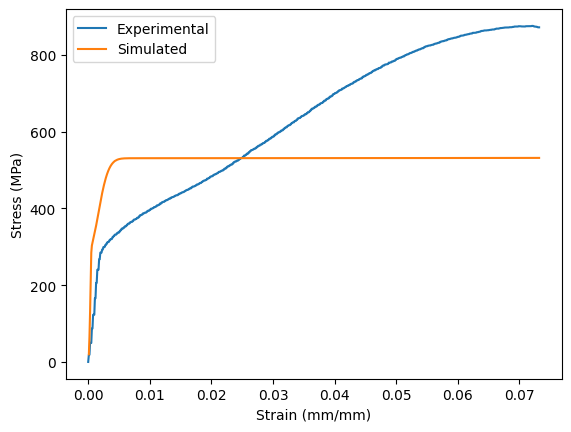

In [9]:
stress_hist = []
for e0, e1 in tqdm.tqdm(zip(strain_stress[:-1,0], strain_stress[1:,0]), total = strain_stress.shape[0]-1):
    de = e1 - e0
    dt = de / assumed_rate

    avg_stress, old_stress, old_state = tmodel(de, dt, d, old_state, old_time, old_stress)
    old_time = old_time + dt
    stress_hist.append(avg_stress)

stress_hist = torch.stack(stress_hist, dim = 0)
plt.figure()
plt.plot(strain_stress[:,0], strain_stress[:,1], label = 'Experimental')
plt.plot(strain_stress[1:,0], stress_hist[:, axial_index], label = 'Simulated')
plt.xlabel('Strain (mm/mm)')
plt.ylabel("Stress (MPa)")
plt.legend(loc='best')
